In [ ]:
import pandas as pd
# Carregar dados de vendas de CSVs
df_vendas = pd.read_csv("vendas_aula7.csv")
df_produtos = pd.read_csv("produtos_aula7.csv")

# Realizar o merge para obter o DataFrame de vendas completo
df_vendas_completo = pd.merge(df_vendas, df_produtos, on='ID_Produto', how='left')
print("DataFrame de Vendas Completo (após merge inicial):")
print(df_vendas_completo.head())

In [ ]:
# Carregar dados adicionais de produtos do Excel
df_produtos_info = pd.read_excel("produtos_info.xlsx")
print("\nDataFrame do Excel (produtos_info):")
# print(df_produtos_info.head())

# Realizar o merge com base no ID_Produto
df_final = pd.merge(df_vendas_completo, df_produtos_info, on='ID_Produto', how='left')
print("\nDataFrame Final (após merge com Excel):")
print(df_final.head())

# Calcular Faturamento Total
df_final["Faturamento"] = df_final["Quantidade"] * df_final["Preco_Venda"]

In [ ]:
faturamento = df_final["Faturamento"]

media_fat = faturamento.mean()
mediana_fat = faturamento.median()
Q1_fat = faturamento.quantile(0.25)
Q3_fat = faturamento.quantile(0.75)
IQR_fat = Q3_fat - Q1_fat
lim_inf_fat = Q1_fat - (1.5 * IQR_fat)
lim_sup_fat = Q3_fat + (1.5 * IQR_fat)
menor_fat = faturamento.min()
maior_fat = faturamento.max()
amplitude_fat = maior_fat - menor_fat

print("\n--- Medidas de Faturamento ---")
print(f"Média Faturamento: {media_fat:.2f}")
print(f"Mediana Faturamento: {mediana_fat:.2f}")
print(f"Q1 Faturamento: {Q1_fat:.2f}")
print(f"Q3 Faturamento: {Q3_fat:.2f}")
print(f"IQR Faturamento: {IQR_fat:.2f}")
print(f"Limite Inferior Faturamento: {lim_inf_fat:.2f}")
print(f"Limite Superior Faturamento: {lim_sup_fat:.2f}")
print(f"Menor Faturamento: {menor_fat:.2f}")
print(f"Maior Faturamento: {maior_fat:.2f}")
print(f"Amplitude Total Faturamento: {amplitude_fat:.2f}")

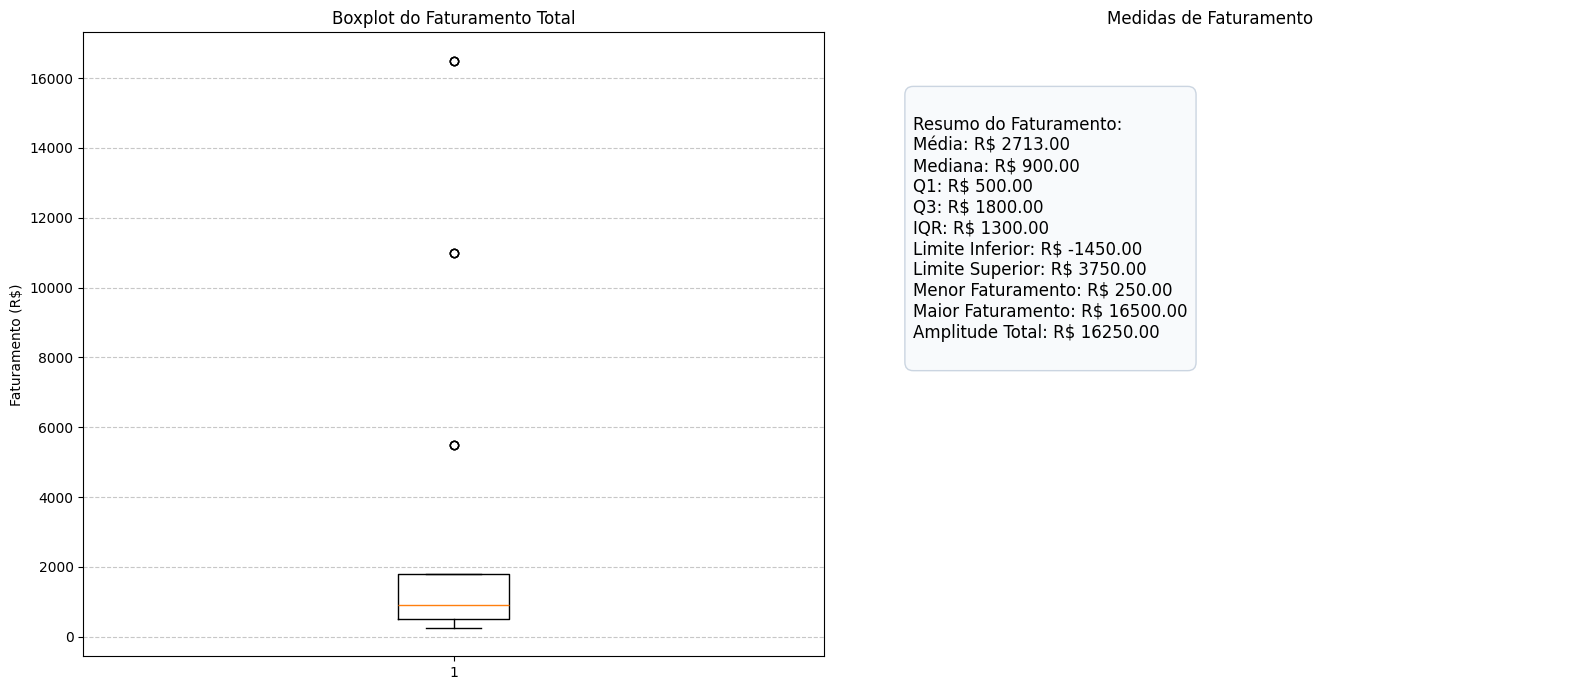

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Boxplot do Faturamento
axes[0].boxplot(faturamento)
axes[0].set_title("Boxplot do Faturamento Total")
axes[0].set_ylabel("Faturamento (R$)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Painel de Texto com Medidas
axes[1].axis('off')
texto_medidas_fat = f"""
Resumo do Faturamento:
Média: R$ {media_fat:.2f}
Mediana: R$ {mediana_fat:.2f}
Q1: R$ {Q1_fat:.2f}
Q3: R$ {Q3_fat:.2f}
IQR: R$ {IQR_fat:.2f}
Limite Inferior: R$ {lim_inf_fat:.2f}
Limite Superior: R$ {lim_sup_fat:.2f}
Menor Faturamento: R$ {menor_fat:.2f}
Maior Faturamento: R$ {maior_fat:.2f}
Amplitude Total: R$ {amplitude_fat:.2f}
"""

axes[1].text(0.1, 0.9, texto_medidas_fat, transform=axes[1].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='#F8FAFC', ec='#CBD5E1', lw=1))
axes[1].set_title("Medidas de Faturamento")

plt.tight_layout()
plt.show()

## 📊 Como Interpretar um Boxplot

### 🎯 Componentes do Boxplot

```
    Outliers Superiores  ●  ●        ← Valores excepcionalmente ALTOS
                         │
                    ┌────┴────┐
                    │         │      ← Q3 (75% dos dados estão abaixo)
                    │         │
         IQR ──→    │   ───   │      ← MEDIANA (50% estão abaixo/acima)
                    │         │         **NÃO é a média!**
                    │         │
                    └────┬────┘      ← Q1 (25% dos dados estão abaixo)
                         │
    Outliers Inferiores  ●  ●        ← Valores excepcionalmente BAIXOS
```

---

### 📋 Elementos Principais

| Elemento | O que representa |
|----------|-----------------|
| **Linha no meio da caixa** | MEDIANA (valor central) |
| **Caixa (box)** | Onde estão 50% dos dados centrais (entre Q1 e Q3) |
| **Altura da caixa** | IQR = Q3 - Q1 (dispersão dos dados centrais) |
| **Bigodes (whiskers)** | Extensão dos dados "normais" (Q1 - 1.5×IQR até Q3 + 1.5×IQR) |
| **Pontos fora** | OUTLIERS (valores atípicos) |

---

### 🔍 Como Analisar

#### **1. Localização dos Dados**
- **Caixa mais acima** = valores geralmente maiores
- **Caixa mais abaixo** = valores geralmente menores
- **Posição da mediana** = onde está o "centro" dos dados

#### **2. Dispersão (Variabilidade)**
- **Caixa estreita** = dados concentrados (pouca variação)
- **Caixa alongada** = dados dispersos (muita variação)
- **Bigodes longos** = dados se estendem por uma grande amplitude

#### **3. Simetria da Distribuição**

**Simétrica:**
```
    ┌────────┐
    │   ───  │  ← Mediana no centro
    └────────┘
```

**Assimétrica à Direita (cauda longa à direita):**
```
    ┌────────┐
    │ ───    │  ← Mediana próxima ao Q1
    └────────┘────────
```
*Interpretação: Maioria dos valores baixos, alguns valores muito altos*

**Assimétrica à Esquerda (cauda longa à esquerda):**
```
    ────────┌────────┐
            │    ─── │  ← Mediana próxima ao Q3
            └────────┘
```
*Interpretação: Maioria dos valores altos, alguns valores muito baixos*

#### **4. Outliers**
- **Muitos outliers superiores** → Vendas/eventos excepcionalmente bons
- **Muitos outliers inferiores** → Vendas/eventos excepcionalmente ruins
- **Poucos ou sem outliers** → Dados mais uniformes

---

### 💡 Interpretando o Boxplot de Faturamento

No contexto do nosso exercício:

- **Q1 (limite inferior da caixa)**: 25% das vendas tiveram faturamento abaixo deste valor
- **Mediana (linha central)**: Metade das vendas faturou menos, metade faturou mais
- **Q3 (limite superior da caixa)**: 75% das vendas tiveram faturamento abaixo deste valor
- **Outliers superiores**: Vendas com faturamento excepcionalmente alto (possíveis grandes pedidos)
- **Outliers inferiores**: Vendas com faturamento excepcionalmente baixo

---

### ⚠️ Importante: Mediana ≠ Média

**O boxplot mostra a MEDIANA, não a MÉDIA!**

- **Mediana** = valor do meio (robusta a outliers)
- **Média** = soma ÷ quantidade (sensível a outliers)

**Exemplo:**
```
Dados: 10, 20, 30, 40, 1000

Mediana = 30  (valor central)
Média = 220   (puxada pelo valor 1000)
```

Se média e mediana são muito diferentes, indica presença de outliers ou assimetria!